In [132]:
import pandas as pd

In [133]:
gsc_pages = pd.read_csv('../data/gsc_pages.csv')
gsc_queries = pd.read_csv('../data/gsc_queries.csv')

print(gsc_pages.head().assign(**{
    'Top pages': gsc_pages['Top pages'].head().str.replace(r'https?://[^/]+', '[client-site]', regex=True)
}))
print(f"gsc_queries loaded: {gsc_queries.shape[0]} rows, {gsc_queries.shape[1]} columns")

                                           Top pages  Clicks  Impressions  \
0                                     [client-site]/     585         4435   
1               [client-site]/blogs/paypal-in-nepal/     349        61503   
2                                [client-site]/zoom/     107         4076   
3  [client-site]/blogs/zoom-not-working-troublesh...     102        26600   
4  [client-site]/blogs/aws-in-2026-latest-service...      29        80547   

      CTR  Position  
0  13.19%      5.27  
1   0.57%      4.46  
2   2.63%     11.57  
3   0.38%      6.22  
4   0.04%      6.44  
gsc_queries loaded: 1000 rows, 5 columns


In [134]:
file_path = '../data/ga4_landing_page.csv'

with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

header_index = None
for i, line in enumerate(lines):
    if line.startswith("Landing page"):
        header_index = i
        break

print("GA4 header found at line:", header_index)

ga4 = pd.read_csv(file_path, skiprows=header_index)

print(ga4.head())

GA4 header found at line: 9
                                  Landing page  Sessions  Active users  \
0   /blogs/aws-in-2026-latest-services-updates       592           525   
1                                            /       572           470   
2  /blogs/simple-comparison-of-zoom-vs-discord       338           337   
3                       /blogs/paypal-in-nepal       257           215   
4  /blogs/amazon-bedrock-aws-ai-platform-guide       232           222   

   New users  Average engagement time per session  Key events  Total revenue  \
0        524                            17.701014           0              0   
1        465                            37.127622           0              0   
2        337                            14.482249           0              0   
3        215                            29.626459           0              0   
4        222                             7.564655           0              0   

   Session key event rate  
0                 

In [135]:
gsc_pages.columns = gsc_pages.columns.str.strip()
gsc_queries.columns = gsc_queries.columns.str.strip()
ga4.columns = ga4.columns.str.strip()

gsc_pages = gsc_pages.rename(columns={'Top pages': 'Page'})
ga4 = ga4.rename(columns={'Landing page': 'Page'})

print("GSC columns:", gsc_pages.columns.tolist())
print("GA4 columns:", ga4.columns.tolist())

GSC columns: ['Page', 'Clicks', 'Impressions', 'CTR', 'Position']
GA4 columns: ['Page', 'Sessions', 'Active users', 'New users', 'Average engagement time per session', 'Key events', 'Total revenue', 'Session key event rate']


In [136]:
def clean_url(col):
    return (
        col.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'https?://[^/]+', '', regex=True)
        .str.rstrip('/')
    )

gsc_pages['Page'] = clean_url(gsc_pages['Page'])
ga4['Page'] = clean_url(ga4['Page'])

ga4 = ga4[ga4['Page'].str.startswith('/')]

print("GSC sample:", gsc_pages['Page'].head(3).tolist())
print("GA4 sample:", ga4['Page'].head(3).tolist())

GSC sample: ['', '/blogs/paypal-in-nepal', '/zoom']
GA4 sample: ['/blogs/aws-in-2026-latest-services-updates', '/blogs/simple-comparison-of-zoom-vs-discord', '/blogs/paypal-in-nepal']


In [137]:
page_metrics = pd.merge(
    gsc_pages,
    ga4,
    on='Page',
    how='inner'
)

print(f"Merged dataset: {page_metrics.shape[0]} rows, {page_metrics.shape[1]} columns")
print(page_metrics.head())

Merged dataset: 74 rows, 12 columns
                                         Page  Clicks  Impressions    CTR  \
0                      /blogs/paypal-in-nepal     349        61503  0.57%   
1                                       /zoom     107         4076  2.63%   
2  /blogs/zoom-not-working-troubleshoot-guide     102        26600  0.38%   
3  /blogs/aws-in-2026-latest-services-updates      29        80547  0.04%   
4                  /cloud-consulting-in-nepal      26         1431  1.82%   

   Position  Sessions  Active users  New users  \
0      4.46       257           215        215   
1     11.57        65            62         59   
2      6.22       140           134        133   
3      6.44       592           525        524   
4     11.50        53            25         22   

   Average engagement time per session  Key events  Total revenue  \
0                            29.626459           0              0   
1                            74.030769           0            

In [138]:
page_metrics = page_metrics.rename(columns={
    'Clicks': 'gsc_clicks',
    'Impressions': 'gsc_impressions',
    'CTR': 'gsc_ctr',
    'Position': 'gsc_position',
    'Sessions': 'ga_sessions',
    'Active users': 'ga_active_users',
    'New users': 'ga_new_users',
    'Average engagement time per session': 'ga_engagement_time',
    'Key events': 'ga_conversions'
})

page_metrics['gsc_ctr'] = page_metrics['gsc_ctr'].str.replace('%', '').astype(float) / 100

print(page_metrics.dtypes)

Page                          str
gsc_clicks                  int64
gsc_impressions             int64
gsc_ctr                   float64
gsc_position              float64
ga_sessions                 int64
ga_active_users             int64
ga_new_users                int64
ga_engagement_time        float64
ga_conversions              int64
Total revenue               int64
Session key event rate      int64
dtype: object


In [139]:
page_metrics['visibility_score'] = page_metrics['gsc_impressions'] * page_metrics['gsc_ctr']
page_metrics['click_to_session_ratio'] = page_metrics['ga_sessions'] / page_metrics['gsc_clicks']
page_metrics['engagement_per_session'] = page_metrics['ga_engagement_time']
page_metrics['engagement_efficiency'] = page_metrics['ga_engagement_time'] / page_metrics['ga_sessions']

print(page_metrics[['Page', 'visibility_score', 'click_to_session_ratio', 'engagement_efficiency']].head())

                                         Page  visibility_score  \
0                      /blogs/paypal-in-nepal          350.5671   
1                                       /zoom          107.1988   
2  /blogs/zoom-not-working-troubleshoot-guide          101.0800   
3  /blogs/aws-in-2026-latest-services-updates           32.2188   
4                  /cloud-consulting-in-nepal           26.0442   

   click_to_session_ratio  engagement_efficiency  
0                0.736390               0.115278  
1                0.607477               1.138935  
2                1.372549               0.262857  
3               20.413793               0.029900  
4                2.038462               0.224635  


In [140]:
page_metrics.sort_values('ga_sessions', ascending=False)[
    ['Page', 'gsc_clicks', 'gsc_impressions', 'ga_sessions', 'ga_engagement_time']
].head(10)

,Page,gsc_clicks,gsc_impressions,ga_sessions,ga_engagement_time
3,/blogs/aws-in-2026-latest-services-updates,29,80547,592,17.701014
27,/blogs/simple-comparison-of-zoom-vs-discord,2,3203,338,14.482249
0,/blogs/paypal-in-nepal,349,61503,257,29.626459
14,/blogs/amazon-bedrock-aws-ai-platform-guide,9,49523,232,7.564655
2,/blogs/zoom-not-working-troubleshoot-guide,102,26600,140,36.800000
45,/cybersecurity,0,145,87,4.954023
13,/blogs/complete-guide-to-aws-database,10,10061,78,6.948718
15,/blogs/what-is-aws-guide-amazon-web-services,8,19555,74,28.337838
1,/zoom,107,4076,65,74.030769
4,/cloud-consulting-in-nepal,26,1431,53,11.905660


In [141]:
def classify(row):
    if row['gsc_impressions'] > 20000 and row['ga_sessions'] < 100:
        return "High visibility / low engagement"
    elif row['ga_engagement_time'] > 30:
        return "High quality content"
    elif row['gsc_clicks'] > 100:
        return "High traffic driver"
    else:
        return "Normal"

page_metrics['category'] = page_metrics.apply(classify, axis=1)

page_metrics[['Page', 'category']]

,Page,category
0,/blogs/paypal-in-nepal,High traffic driver
1,/zoom,High quality content
2,/blogs/zoom-not-working-troubleshoot-guide,High quality content
3,/blogs/aws-in-2026-latest-services-updates,Normal
4,/cloud-consulting-in-nepal,Normal
...,...,...
69,/plans/zoom-webinar-plan,Normal
70,/faq/what-cloud-services-do-you-offer,Normal
71,/cloud-service,Normal
72,/faq/how-secure-is-your-cloud-infrastructure,Normal


In [142]:
print(gsc_queries.columns.tolist())
print(gsc_queries.shape)

['Top queries', 'Clicks', 'Impressions', 'CTR', 'Position']
(1000, 5)


In [143]:
import os

query_files = {
    'aws_bedrock': '../data/aws_bedrock_queries.csv',
    'aws_updates': '../data/aws_updates_queries.csv',
    'paypal_nepal': '../data/paypal_in_nepal_queries.csv',
    'zoom': '../data/zoom_queries.csv',
    'zoom_troubleshoot': '../data/zoom_troubleshoot_queries.csv',
    'zoom_discord': '../data/zoom_discord_queries.csv',
}

query_dfs = {}
for name, path in query_files.items():
    df = pd.read_csv(path)
    query_dfs[name] = df
    print(f"{name}: {df.shape[0]} rows")

aws_bedrock: 480 rows
aws_updates: 1000 rows
paypal_nepal: 510 rows
zoom: 52 rows
zoom_troubleshoot: 518 rows
zoom_discord: 51 rows


In [144]:
for name, df in query_dfs.items():
    print(f"\n{name}:")
    print(df.head(3))


aws_bedrock:
                   Top queries  Clicks  Impressions    CTR  Position
0  amazon bedrock 2026 updates       1           13  7.69%      5.77
1                  aws bedrock       1           11  9.09%     17.36
2               how many total       1            1   100%      6.00

aws_updates:
                               Top queries  Clicks  Impressions    CTR  \
0                    aws new features 2026       1           58  1.72%   
1  how many aws services are there in 2026       1           31  3.23%   
2                          aws trends 2026       1           15  6.67%   

   Position  
0      6.69  
1      3.81  
2      6.00  

paypal_nepal:
                    Top queries  Clicks  Impressions    CTR  Position
0               paypal in nepal      44         5772  0.76%      5.70
1  is paypal available in nepal      17         3111  0.55%      4.40
2     does paypal work in nepal      12         1835  0.65%      4.27

zoom:
                  Top queries  Clicks  Im

In [145]:
def clean_query_df(df, page_label):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'Top queries': 'query'})
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    df['ctr'] = df['ctr'].str.replace('%', '').astype(float) / 100
    df['page'] = page_label
    return df

query_dfs_clean = {
    'aws_bedrock': clean_query_df(query_dfs['aws_bedrock'], '/blogs/amazon-bedrock-aws-ai-platform-guide'),
    'aws_updates': clean_query_df(query_dfs['aws_updates'], '/blogs/aws-in-2026-latest-services-updates'),
    'paypal_nepal': clean_query_df(query_dfs['paypal_nepal'], '/blogs/paypal-in-nepal'),
    'zoom': clean_query_df(query_dfs['zoom'], '/zoom'),
    'zoom_troubleshoot': clean_query_df(query_dfs['zoom_troubleshoot'], '/blogs/zoom-not-working-troubleshoot-guide'),
    'zoom_discord': clean_query_df(query_dfs['zoom_discord'], '/blogs/simple-comparison-of-zoom-vs-discord'),
}

all_queries = pd.concat(query_dfs_clean.values(), ignore_index=True)

print(all_queries.shape)
print(all_queries.head())

(2611, 6)
                            query  clicks  impressions     ctr  position  \
0     amazon bedrock 2026 updates       1           13  0.0769      5.77   
1                     aws bedrock       1           11  0.0909     17.36   
2                  how many total       1            1  1.0000      6.00   
3        aws bedrock updates 2026       0         1643  0.0000      5.66   
4  aws bedrock updates april 2026       0          672  0.0000      7.36   

                                          page  
0  /blogs/amazon-bedrock-aws-ai-platform-guide  
1  /blogs/amazon-bedrock-aws-ai-platform-guide  
2  /blogs/amazon-bedrock-aws-ai-platform-guide  
3  /blogs/amazon-bedrock-aws-ai-platform-guide  
4  /blogs/amazon-bedrock-aws-ai-platform-guide  


In [146]:
troubleshooting = [
    'not working', 'fix', 'issue', 'problem', 'error', 'troubleshoot',
    "can't", 'cant', 'failed', 'slow', 'unable', 'connecting', "won't",
    "isn't", 'connection', 'launch'
]
transactional = [
    'buy', 'subscribe', 'get', 'order', 'sign up', 'register',
    'download', 'install', 'start'
]
commercial = [
    'price', 'cost', 'plan', 'license', 'reseller', 'provider',
    'service', 'best', 'alternative', 'subscription', 'package',
    'authorized', 'pricing', 'authorised', 'vs', 'compare',
    'comparison', 'differences', 'difference', 'better'
]
informational = [
    'what', 'how', 'why', 'when', 'where', 'who', 'is', 'are', 'does',
    'do', 'can', 'which', 'will', 'guide', 'tutorial', 'explain',
    'available', 'legal', 'work', 'use', 'come', 'news', 'meaning'
]
local = [
    'in nepal', 'near me', 'in Nepal', 'local'
]

def classify_intent(query):
    q = query.lower()
    if any(word in q for word in troubleshooting):
        return 'Troubleshooting'
    elif any(word in q for word in transactional):
        return 'Transactional'
    elif any(word in q for word in commercial):
        return 'Commercial'
    elif any(word in q for word in local):
        return 'Local'
    elif any(word in q for word in informational):
        return 'Informational'
    else:
        return 'Informational'

all_queries['intent'] = all_queries['query'].apply(classify_intent)

print(all_queries['intent'].value_counts())
print()
print(all_queries.groupby(['page', 'intent']).size().unstack(fill_value=0))

intent
Informational      1661
Commercial          506
Troubleshooting     263
Local               146
Transactional        35
Name: count, dtype: int64

intent                                       Commercial  Informational  Local  \
page                                                                            
/blogs/amazon-bedrock-aws-ai-platform-guide          87            386      0   
/blogs/aws-in-2026-latest-services-updates          346            640      0   
/blogs/paypal-in-nepal                                5            353    143   
/blogs/simple-comparison-of-zoom-vs-discord          34             16      1   
/blogs/zoom-not-working-troubleshoot-guide            9            253      0   
/zoom                                                25             13      2   

intent                                       Transactional  Troubleshooting  
page                                                                         
/blogs/amazon-bedrock-aws-ai-platform-gui

In [147]:
intent_summary = all_queries.groupby(['page', 'intent']).agg(
    query_count=('query', 'count'),
    total_clicks=('clicks', 'sum'),
    total_impressions=('impressions', 'sum'),
    avg_position=('position', 'mean')
).reset_index()

dominant_intent = all_queries.groupby('page')['intent'].agg(
    lambda x: x.value_counts().index[0]
).reset_index().rename(columns={'intent': 'dominant_intent'})

page_intent = page_metrics.merge(
    dominant_intent,
    left_on='Page',
    right_on='page',
    how='left'
).drop(columns='page')

print(page_intent[['Page', 'dominant_intent', 'ga_engagement_time', 'engagement_efficiency']].dropna())

                                           Page dominant_intent  \
0                        /blogs/paypal-in-nepal   Informational   
1                                         /zoom      Commercial   
2    /blogs/zoom-not-working-troubleshoot-guide   Informational   
3    /blogs/aws-in-2026-latest-services-updates   Informational   
14  /blogs/amazon-bedrock-aws-ai-platform-guide   Informational   
27  /blogs/simple-comparison-of-zoom-vs-discord      Commercial   

    ga_engagement_time  engagement_efficiency  
0            29.626459               0.115278  
1            74.030769               1.138935  
2            36.800000               0.262857  
3            17.701014               0.029900  
14            7.564655               0.032606  
27           14.482249               0.042847  


In [148]:
import os
os.makedirs('../output/charts/', exist_ok=True)

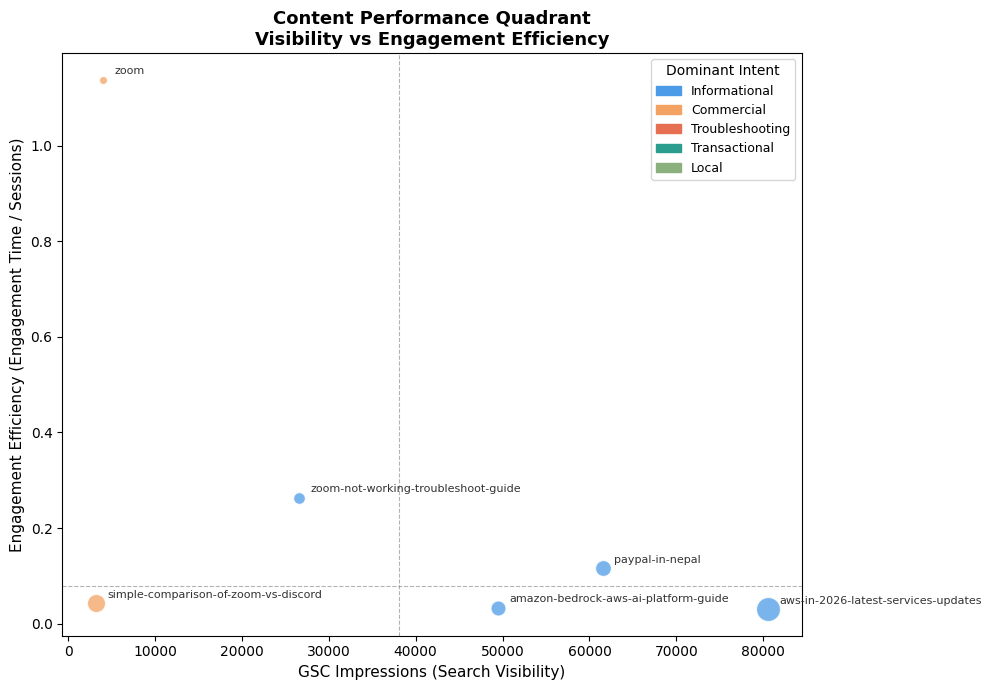

Chart saved.


In [149]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7))

# Use only pages with intent data
plot_data = page_intent.dropna(subset=['dominant_intent'])

colors = {
    'Informational': '#4C9BE8',
    'Commercial': '#F4A261',
    'Troubleshooting': '#E76F51',
    'Transactional': '#2A9D8F',
    'Local': '#8AB17D'
}

for _, row in plot_data.iterrows():
    color = colors.get(row['dominant_intent'], '#999999')
    ax.scatter(
        row['gsc_impressions'],
        row['engagement_efficiency'],
        color=color,
        s=row['ga_sessions'] * 0.5,
        alpha=0.75,
        edgecolors='white',
        linewidth=0.8
    )
    ax.annotate(
        row['Page'].replace('/blogs/', '').replace('/', ''),
        (row['gsc_impressions'], row['engagement_efficiency']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        color='#333333'
    )

# Quadrant lines
ax.axvline(x=plot_data['gsc_impressions'].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(y=plot_data['engagement_efficiency'].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Labels
ax.set_xlabel('GSC Impressions (Search Visibility)', fontsize=11)
ax.set_ylabel('Engagement Efficiency (Engagement Time / Sessions)', fontsize=11)
ax.set_title('Content Performance Quadrant\nVisibility vs Engagement Efficiency', fontsize=13, fontweight='bold')

# Legend for intent
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=legend_patches, title='Dominant Intent', loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../output/charts/quadrant_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")